In [1]:
# CELDA 1 — Librerías y configuración de GPU
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
print("Nombre GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detectada")

# Rutas
BASE_PATH = r"C:\Users\David\Documents\Master-Big-Data-Data-Sciencee-e-Inteligencia-Artificial\TFM\AeroGPT\data\CMAPSS"
RAW_PATH = os.path.join(BASE_PATH, "raw")
MODEL_PATH = os.path.join(BASE_PATH, "models_3")
FIG_PATH = os.path.join(BASE_PATH, "figures_3")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)


Usando dispositivo: cuda
Nombre GPU: NVIDIA GeForce RTX 3050 Laptop GPU


FUNCIONES DE CARGA Y PREPROCESAMIENTO

In [2]:
def load_cmapss(path):
    df = pd.read_csv(path, sep=" ", header=None)
    df.dropna(axis=1, inplace=True)
    col_names = ["unit_nr", "time_cycles"] + [f"setting_{i}" for i in range(1,4)] + [f"s_{i}" for i in range(1,22)]
    df.columns = col_names
    return df

def add_rul(train_df, cap_value=125):
    max_cycles = train_df.groupby("unit_nr")["time_cycles"].max().reset_index()
    max_cycles.columns = ["unit_nr", "max_cycle"]
    df = train_df.merge(max_cycles, on="unit_nr", how="left")
    df["RUL"] = df["max_cycle"] - df["time_cycles"]
    df["RUL"] = df["RUL"].clip(upper=cap_value)
    return df.drop(columns=["max_cycle"])

def scale_features(train_df, test_df, feature_cols):
    train_scaled, test_scaled = [], []
    global_scaler = StandardScaler()
    global_scaler.fit(train_df[feature_cols])
    for unit in train_df["unit_nr"].unique():
        df_unit = train_df[train_df["unit_nr"]==unit].copy()
        scaler = StandardScaler()
        df_unit[feature_cols] = scaler.fit_transform(df_unit[feature_cols])
        train_scaled.append(df_unit)
    for unit in test_df["unit_nr"].unique():
        df_unit = test_df[test_df["unit_nr"]==unit].copy()
        df_unit[feature_cols] = global_scaler.transform(df_unit[feature_cols])
        test_scaled.append(df_unit)
    train_df = pd.concat(train_scaled).sort_values(["unit_nr", "time_cycles"])
    test_df = pd.concat(test_scaled).sort_values(["unit_nr", "time_cycles"])
    return train_df, test_df, global_scaler


SECUENCIAS PARA ENTRENAMIENTO Y TEST

In [3]:
def create_sequences(df, feature_cols, target_col, window_size=50, step_size=2):
    X, y = [], []
    for unit in df["unit_nr"].unique():
        unit_df = df[df["unit_nr"]==unit].sort_values("time_cycles")
        features = unit_df[feature_cols].values
        targets = unit_df[target_col].values
        if len(unit_df) >= window_size:
            for i in range(0, len(unit_df) - window_size + 1, step_size):
                seq = features[i:i+window_size]
                if np.isnan(seq).any():
                    continue
                X.append(seq)
                y.append(targets[i+window_size-1])
    return np.array(X), np.array(y)

def create_sequences_test(test_df, rul_df, feature_cols, window_size=50):
    X_test, y_test = [], []
    unit_ids = test_df["unit_nr"].unique()
    for i, unit in enumerate(unit_ids):
        part = test_df[test_df["unit_nr"]==unit].sort_values("time_cycles")
        features = part[feature_cols].values
        if len(features) < window_size:
            padding = np.zeros((window_size - len(features), features.shape[1]))
            features = np.vstack([padding, features])
        else:
            features = features[-window_size:]
        X_test.append(features)
        y_test.append(rul_df.iloc[i,0])
    return np.array(X_test), np.array(y_test)


DATASET y MODELO

In [4]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim1=512, hidden_dim2=256, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru1 = nn.GRU(input_dim, hidden_dim1, num_layers=2, dropout=dropout, batch_first=True)
        self.gru2 = nn.GRU(hidden_dim1, hidden_dim2, num_layers=2, dropout=dropout, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim2, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.gru1(x)
        out, _ = self.gru2(out)
        out = out[:,-1,:]
        out = self.relu(self.fc1(out))
        return self.fc2(out)


ENTRENAMIENTO Y EVALUACION

In [5]:
def train_model(model, train_loader, val_loader, epochs=500, lr=1e-4, fd_name="FD"):
    """
    Entrena el modelo GRU, con Early Stopping, scheduler y GPU.
    """
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=80, factor=0.5)

    best_val_loss = np.inf
    patience = 80
    wait = 0

    train_losses_hist, val_losses_hist = [], []

    for epoch in range(1, epochs+1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_loss = criterion(model(X_val), y_val)
                val_losses.append(val_loss.item())

        train_mean, val_mean = np.mean(train_losses), np.mean(val_losses)
        train_losses_hist.append(train_mean)
        val_losses_hist.append(val_mean)

        scheduler.step(val_mean)

        print(f"{fd_name} | Epoch {epoch:03d} | Train Loss: {train_mean:.4f} | Val Loss: {val_mean:.4f}")

        # Early stopping
        if val_mean < best_val_loss:
            best_val_loss = val_mean
            wait = 0
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, f"best_model_{fd_name}.pth"))
        else:
            wait += 1
            if wait >= patience:
                print(f"{fd_name} | ⏹ Early stopping activado en epoch {epoch}")
                break

    # Gráfica de pérdida
    plt.figure(figsize=(10,5))
    plt.plot(train_losses_hist, label="Train Loss")
    plt.plot(val_losses_hist, label="Val Loss")
    plt.title(f"{fd_name} - Curva de entrenamiento")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIG_PATH, f"loss_curve_{fd_name}.png"))
    plt.show()

    return model


def evaluate_model(model, test_loader, fd_name="FD"):
    """
    Evalúa el modelo en test y genera gráfica RUL real vs predicho.
    """
    model.eval()
    model.to(device)

    preds_all, y_all = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            preds_all.extend(preds.cpu().numpy())
            y_all.extend(y_batch.cpu().numpy())

    preds_all, y_all = np.array(preds_all).flatten(), np.array(y_all).flatten()
    mae = np.mean(np.abs(preds_all - y_all))
    print(f"{fd_name} | MAE Test final: {mae:.4f}")

    # Gráfica RUL real vs predicho
    plt.figure(figsize=(12,6))
    plt.plot(y_all, label="RUL real", alpha=0.7)
    plt.plot(preds_all, label="RUL predicho", alpha=0.7)
    plt.title(f"{fd_name} - RUL Real vs Predicho")
    plt.xlabel("Muestra")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIG_PATH, f"RUL_pred_{fd_name}.png"))
    plt.show()

    return mae


EJECUCION


   PROCESANDO FD001

GRUModel(
  (gru1): GRU(24, 512, num_layers=2, batch_first=True, dropout=0.2)
  (gru2): GRU(512, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
FD001 | Epoch 001 | Train Loss: 1089.3176 | Val Loss: 484.1402
FD001 | Epoch 002 | Train Loss: 102.0651 | Val Loss: 422.5459
FD001 | Epoch 003 | Train Loss: 32.7129 | Val Loss: 444.9977
FD001 | Epoch 004 | Train Loss: 17.8441 | Val Loss: 512.3383
FD001 | Epoch 005 | Train Loss: 14.8342 | Val Loss: 498.8203
FD001 | Epoch 006 | Train Loss: 7.5471 | Val Loss: 486.1082
FD001 | Epoch 007 | Train Loss: 5.8347 | Val Loss: 515.4445
FD001 | Epoch 008 | Train Loss: 4.7880 | Val Loss: 495.2349
FD001 | Epoch 009 | Train Loss: 5.5697 | Val Loss: 634.1460
FD001 | Epoch 010 | Train Loss: 5.3845 | Val Loss: 557.8426
FD001 | Epoch 011 | Train Loss: 3.1291 | Val Loss: 567.4209
FD001 | Epoch 012 | Trai

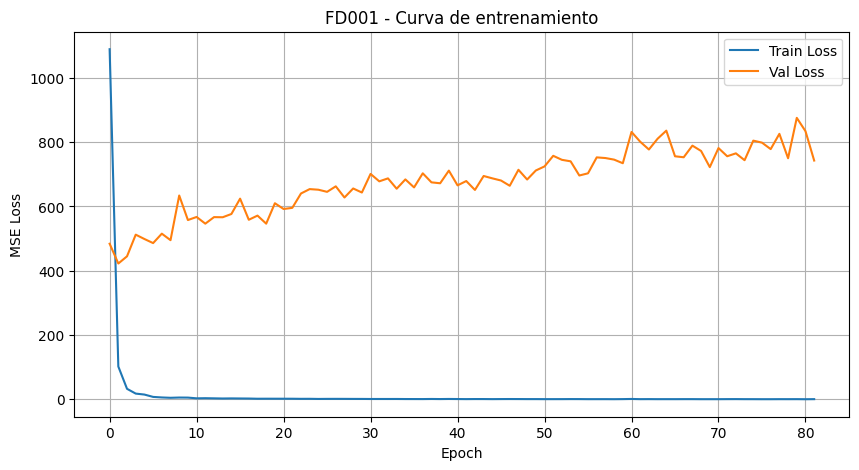

FD001 | MAE Test final: 21.3183


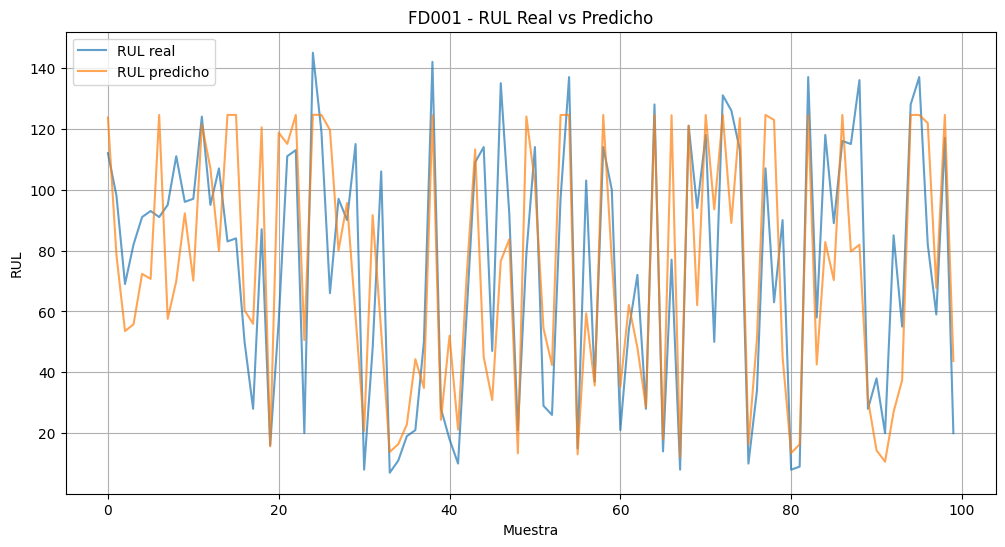


   PROCESANDO FD002

GRUModel(
  (gru1): GRU(24, 512, num_layers=2, batch_first=True, dropout=0.2)
  (gru2): GRU(512, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
FD002 | Epoch 001 | Train Loss: 1972.7313 | Val Loss: 2598.5340
FD002 | Epoch 002 | Train Loss: 1718.0188 | Val Loss: 2628.0505
FD002 | Epoch 003 | Train Loss: 1718.1621 | Val Loss: 2628.9928
FD002 | Epoch 004 | Train Loss: 1725.8948 | Val Loss: 2617.3127
FD002 | Epoch 005 | Train Loss: 1709.0145 | Val Loss: 2393.1776
FD002 | Epoch 006 | Train Loss: 696.3295 | Val Loss: 1055.3540
FD002 | Epoch 007 | Train Loss: 202.2740 | Val Loss: 1299.1987
FD002 | Epoch 008 | Train Loss: 55.3835 | Val Loss: 1274.5217
FD002 | Epoch 009 | Train Loss: 17.0282 | Val Loss: 1386.5175
FD002 | Epoch 010 | Train Loss: 10.7158 | Val Loss: 1322.4211


KeyboardInterrupt: 

In [6]:
FD_LIST = ["FD001", "FD002", "FD003", "FD004"]
resultados = []

for fd in FD_LIST:
    print("\n==============================")
    print(f"   PROCESANDO {fd}")
    print("==============================\n")

    train_path = os.path.join(RAW_PATH, f"train_{fd}.txt")
    test_path  = os.path.join(RAW_PATH, f"test_{fd}.txt")
    rul_path   = os.path.join(RAW_PATH, f"RUL_{fd}.txt")

    rul_df = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])
    train_df = load_cmapss(train_path)
    test_df  = load_cmapss(test_path)
    train_df = add_rul(train_df)

    feature_cols = [c for c in train_df.columns if c.startswith("s_") or c.startswith("setting_")]
    train_df, test_df, _ = scale_features(train_df, test_df, feature_cols)

    X_train, y_train = create_sequences(train_df, feature_cols, "RUL", window_size=50, step_size=1)
    X_test, y_test = create_sequences_test(test_df, rul_df, feature_cols, window_size=50)

    # Añadir datos con ruido para duplicar datps
    noise_factor = 0.01
    X_train_noisy = X_train + np.random.normal(0, noise_factor, X_train.shape)
    X_train = np.concatenate([X_train, X_train_noisy])
    y_train = np.concatenate([y_train, y_train])


    train_ds = SequenceDataset(X_train, y_train)
    test_ds  = SequenceDataset(X_test, y_test)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=64)

    model = GRUModel(len(feature_cols))
    print(model)

    model = train_model(model, train_loader, test_loader, epochs=500, lr=1e-3, fd_name=fd)
    mae = evaluate_model(model, test_loader, fd_name=fd)

    # Guardar modelo
    torch.save(model.state_dict(), os.path.join(MODEL_PATH, f"model_{fd}.pth"))
    resultados.append([fd, mae])

# Guardar CSV final
df_res = pd.DataFrame(resultados, columns=["FD", "MAE"])
df_res.to_csv(os.path.join(BASE_PATH, "resultados_finales.csv"), index=False)
print("\n\n✅ PROCESO COMPLETO — Modelos, gráficas y CSV generados.")


Comparativa Resultados

In [ ]:
import seaborn as sns

# MAE comparativo
plt.figure(figsize=(8,5))
sns.barplot(x=df_res["FD"], y=df_res["MAE"], palette="viridis")
plt.title("MAE final por FD")
plt.ylabel("MAE")
plt.xlabel("FD")
plt.savefig(os.path.join(FIG_PATH, "MAE_comparativo.png"))
plt.show()

# RUL real vs predicho — superposición de los 4 FD
plt.figure(figsize=(14,6))
for fd in FD_LIST:
    test_path  = os.path.join(RAW_PATH, f"test_{fd}.txt")
    rul_path   = os.path.join(RAW_PATH, f"RUL_{fd}.txt")
    rul_df = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])
    test_df  = load_cmapss(test_path)
    feature_cols = [c for c in test_df.columns if c.startswith("s_") or c.startswith("setting_")]
    _, y_test = create_sequences_test(test_df, rul_df, feature_cols, window_size=50)

    model = GRUModel(len(feature_cols))
    model.load_state_dict(torch.load(os.path.join(MODEL_PATH, f"model_{fd}.pth")))
    model.to(device)
    model.eval()
    X_test, _ = create_sequences_test(test_df, rul_df, feature_cols, window_size=50)
    test_ds  = SequenceDataset(X_test, y_test)
    test_loader  = DataLoader(test_ds, batch_size=64)
    
    preds_all, y_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            preds_all.extend(preds.cpu().numpy())
            y_all.extend(y_batch.numpy())
    plt.plot(y_all, label=f"{fd} - real")
    plt.plot(preds_all, '--', label=f"{fd} - predicho")
plt.title("RUL real vs predicho para todos los FD")
plt.xlabel("Muestra")
plt.ylabel("RUL")
plt.legend()
plt.savefig(os.path.join(FIG_PATH, "RUL_comparativo.png"))
plt.show()
